In [34]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akshatgupta7/crop-yield-in-indian-states-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'crop-yield-in-indian-states-dataset' dataset.
Path to dataset files: /kaggle/input/crop-yield-in-indian-states-dataset


In [95]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score,mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
import joblib

##Data Preprocessing

In [36]:
print(os.listdir(path))

['crop_yield.csv']


In [37]:
file_path = os.path.join(path, "crop_yield.csv")
df = pd.read_csv(file_path)

In [38]:
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [40]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
19684,False
19685,False
19686,False
19687,False


###Encoding

In [41]:
# columns to drop=>Production
df=df.drop(["Production"],axis=1)

In [42]:
df.head()

,Crop,Crop_Year,Season,State,Area,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,2051.4,165500.63,539.09,0.420909


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Annual_Rainfall  19689 non-null  float64
 6   Fertilizer       19689 non-null  float64
 7   Pesticide        19689 non-null  float64
 8   Yield            19689 non-null  float64
dtypes: float64(5), int64(1), object(3)
memory usage: 1.4+ MB


###Checking which to do label-encoding

In [44]:
df["Crop"].value_counts()

,count
Crop,
Rice,1197
Maize,975
Moong(Green Gram),740
Urad,733
Groundnut,725
Sesamum,685
Potato,628
Sugarcane,605
Wheat,545


In [45]:
df["Season"].value_counts()

,count
Season,
Kharif,8232
Rabi,5742
Whole Year,3717
Summer,1195
Autumn,414
Winter,389


In [46]:
df["State"].value_counts()

,count
State,
Karnataka,1432
Andhra Pradesh,1266
West Bengal,1094
Chhattisgarh,915
Bihar,896
Madhya Pradesh,845
Uttar Pradesh,825
Tamil Nadu,822
Gujarat,817


In [47]:
# one-hot=> Crop,Season,State

In [48]:
df = pd.get_dummies(df,columns=["Crop","Season","State"],drop_first=True)

In [49]:
df.head()

,Crop_Year,Area,Annual_Rainfall,Fertilizer,Pesticide,Yield,Crop_Arhar/Tur,Crop_Bajra,Crop_Banana,Crop_Barley,...,State_Odisha,State_Puducherry,State_Punjab,State_Sikkim,State_Tamil Nadu,State_Telangana,State_Tripura,State_Uttar Pradesh,State_Uttarakhand,State_West Bengal
0,1997,73814.0,2051.4,7024878.38,22882.34,0.796087,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1997,6637.0,2051.4,631643.29,2057.47,0.710435,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1997,796.0,2051.4,75755.32,246.76,0.238333,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1997,19656.0,2051.4,1870661.52,6093.36,5238.051739,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1997,1739.0,2051.4,165500.63,539.09,0.420909,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 94 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Crop_Year                   19689 non-null  int64  
 1   Area                        19689 non-null  float64
 2   Annual_Rainfall             19689 non-null  float64
 3   Fertilizer                  19689 non-null  float64
 4   Pesticide                   19689 non-null  float64
 5   Yield                       19689 non-null  float64
 6   Crop_Arhar/Tur              19689 non-null  bool   
 7   Crop_Bajra                  19689 non-null  bool   
 8   Crop_Banana                 19689 non-null  bool   
 9   Crop_Barley                 19689 non-null  bool   
 10  Crop_Black pepper           19689 non-null  bool   
 11  Crop_Cardamom               19689 non-null  bool   
 12  Crop_Cashewnut              19689 non-null  bool   
 13  Crop_Castor seed            196

##Train-test splitting + Scaling

In [52]:
x=df.drop(columns=["Yield"])
y=df["Yield"]
x.head()

,Crop_Year,Area,Annual_Rainfall,Fertilizer,Pesticide,Crop_Arhar/Tur,Crop_Bajra,Crop_Banana,Crop_Barley,Crop_Black pepper,...,State_Odisha,State_Puducherry,State_Punjab,State_Sikkim,State_Tamil Nadu,State_Telangana,State_Tripura,State_Uttar Pradesh,State_Uttarakhand,State_West Bengal
0,1997,73814.0,2051.4,7024878.38,22882.34,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1997,6637.0,2051.4,631643.29,2057.47,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1997,796.0,2051.4,75755.32,246.76,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1997,19656.0,2051.4,1870661.52,6093.36,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1997,1739.0,2051.4,165500.63,539.09,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [53]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

In [54]:
x_train.shape

(15751, 93)

In [55]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [56]:
x_train[0]

array([ 0.29439188, -0.2393997 ,  2.33827732, -0.2499613 , -0.22350624,
       -0.16162852, -0.16652523, -0.11020421, -0.12569938, -0.08152694,
       -0.06026576, -0.08270238, -0.12280161, -0.09401483, -0.09805492,
       -0.15680741, -0.08347705, -0.1462853 , -0.1187431 , -0.12569938,
       -0.15870965,  5.1235598 , -0.05643147, -0.14005067, -0.16368475,
       -0.09672629, -0.06183727, -0.1251772 , -0.22794779, -0.12828039,
       -0.10476454, -0.19796417, -0.07622981, -0.09838438, -0.03906454,
       -0.1531561 , -0.13428542, -0.08688001, -0.14099032, -0.01781968,
       -0.13477458, -0.18458874, -0.1614216 , -0.16490746, -0.25490456,
       -0.09122571, -0.09571817, -0.18751095, -0.15891974, -0.13599034,
       -0.17975238, -0.1531561 , -0.1179156 , -0.10351869, -0.13863017,
       -0.13354856, -0.19412275, -0.16991735, -0.07953031,  1.18104228,
       -0.64227646, -0.25348916, -0.4834538 , -0.14308372, -0.11846787,
       -0.19761758, -0.21918133, -0.22092555, -0.10130316,  8.79

##Model Training + Evaluation

In [57]:
model = LinearRegression()
model.fit(x_train,y_train)


LinearRegression()

In [58]:
y_pred= model.predict(x_test)

In [59]:
y_pred

array([ 12.62109056,   0.82516812,  -8.52140109, ..., 153.18530665,
        18.36850581,  23.34825891])

In [60]:
mean_squared_error(y_test,y_pred)

151851.10307294913

In [61]:
r2_score(y_test,y_pred)

0.8104798453951725

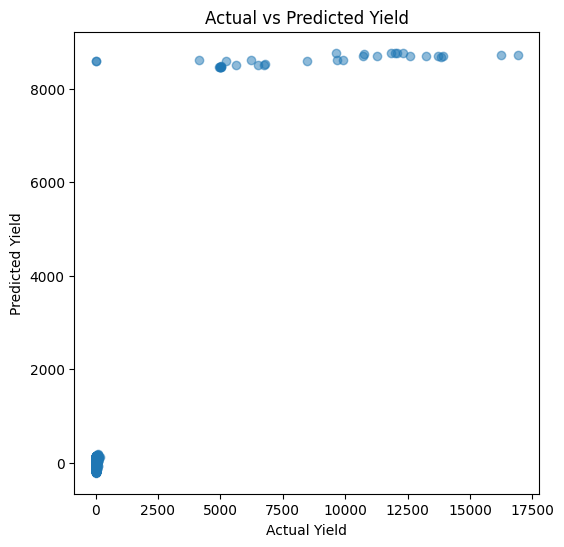

In [64]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.show()

In [65]:
model.coef_

array([ 6.56019890e+00, -6.66813021e+00,  5.10991009e+00, -2.44870265e+00,
        2.79562525e+00,  2.98755282e+00,  1.72638729e+00,  1.79878549e+00,
        2.17953931e+00,  1.96110985e+00, -2.76816745e-01,  9.25953959e-01,
        1.32891988e+00,  8.03537895e+02, -2.35344168e+00,  3.08483987e+00,
        1.42098471e+00, -2.58892534e+00, -8.70163260e-01,  8.80704152e-01,
        3.48622957e+00,  3.97884479e+00, -9.02188310e-01,  1.79808127e+00,
        2.69549903e+00,  2.60329517e+00,  4.94253568e-01,  2.52190050e+00,
        4.81316878e+00,  2.57117404e+00,  1.79875300e+00,  1.39569128e+00,
        9.01303941e-01,  1.85079840e+00, -7.01980183e-01,  1.52682363e+00,
        3.98233358e+00,  1.51761138e+00,  3.05344429e+00, -3.54093229e-01,
        2.90393436e+00,  2.02494629e+00,  3.20407349e+00,  3.57674395e+00,
        9.86581693e+00,  1.14581818e+00, -1.08286914e+00,  1.32711060e+00,
        1.60606369e+00,  2.69270711e+00,  5.72725835e+00,  1.96252230e+00,
       -1.58302700e-01,  

In [68]:
coefficients = model.coef_

feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": coefficients
})

feature_importance["Absolute"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Absolute",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute
13,Crop_Coconut,803.537895,803.537895
76,State_Kerala,-30.576340,30.576340
69,State_Goa,-28.590126,28.590126
62,Season_Whole Year,28.392223,28.392223
67,State_Chhattisgarh,-22.959971,22.959971
...,...,...,...
26,Crop_Khesari,0.494254,0.494254
88,State_Telangana,0.413640,0.413640
39,Crop_Other Summer Pulses,-0.354093,0.354093
10,Crop_Cardamom,-0.276817,0.276817


##Model2: Decision Tree

In [81]:
model2= DecisionTreeRegressor(random_state=1)
model2.fit(x_train,y_train)

DecisionTreeRegressor(random_state=1)

In [83]:
y_pred_tree = model2.predict(x_test)

In [84]:
r2_score(y_test,y_pred_tree)


0.937177782825814

In [86]:
print("Train R2:", r2_score(y_train, model2.predict(x_train)))
print("Test R2:", r2_score(y_test, model2.predict(x_test)))

Train R2: 1.0
Test R2: 0.937177782825814


##Testing Model: Reducing overfititng of Decision Tree

In [88]:
for d in range(2,20):
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(x_train, y_train)

    train_r2 = r2_score(y_train, model.predict(x_train))
    test_r2 = r2_score(y_test, model.predict(x_test))

    print(f"Depth: {d}")
    print("Train R2:", round(train_r2,3))
    print("Test  R2:", round(test_r2,3))
    print("-"*30)

Depth: 2
Train R2: 0.887
Test  R2: 0.857
------------------------------
Depth: 3
Train R2: 0.92
Test  R2: 0.925
------------------------------
Depth: 4
Train R2: 0.951
Test  R2: 0.944
------------------------------
Depth: 5
Train R2: 0.973
Test  R2: 0.965
------------------------------
Depth: 6
Train R2: 0.983
Test  R2: 0.966
------------------------------
Depth: 7
Train R2: 0.986
Test  R2: 0.97
------------------------------
Depth: 8
Train R2: 0.989
Test  R2: 0.973
------------------------------
Depth: 9
Train R2: 0.994
Test  R2: 0.953
------------------------------
Depth: 10
Train R2: 0.996
Test  R2: 0.971
------------------------------
Depth: 11
Train R2: 0.998
Test  R2: 0.939
------------------------------
Depth: 12
Train R2: 0.999
Test  R2: 0.958
------------------------------
Depth: 13
Train R2: 0.999
Test  R2: 0.936
------------------------------
Depth: 14
Train R2: 0.999
Test  R2: 0.937
------------------------------
Depth: 15
Train R2: 1.0
Test  R2: 0.964
---------------------

##Final Model : Desicsion Tree (8)

In [91]:
final_model = DecisionTreeRegressor(max_depth=8, random_state=42)
final_model.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=42)

In [93]:
def evaluate_model(name, model):
    y_pred = model.predict(x_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    train_r2 = r2_score(y_train, model.predict(x_train))
    test_r2 = r2_score(y_test, model.predict(x_test))

    print(f"Model: {name}")
    print("Train R2:", round(train_r2,3))
    print("Test  R2:", round(test_r2,3))
    print("MAE:", round(mae,3))
    print("RMSE:", round(rmse,3))
    print("-"*40)


evaluate_model("Decision Tree", final_model)

Model: Decision Tree
Train R2: 0.989
Test  R2: 0.973
MAE: 10.47
RMSE: 147.379
----------------------------------------


In [94]:
n = x_test.shape[0]
p = x_test.shape[1]
r2 = r2_score(y_test, model.predict(x_test))
adjusted_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

print("Adjusted R2:", adjusted_r2)

Adjusted R2: 0.9722354351175443
